In [13]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cauvery_rivers = gpd.read_file(
    r"G:\OCR\hydroriver\Cauvery_Rivers.shp"
)

print("River Segments:", len(cauvery_rivers))

River Segments: 4549


In [14]:
cauvery_rivers[[
    "HYRIV_ID",
    "NEXT_DOWN",
    "LENGTH_KM",
    "ORD_STRA",
    "DIS_AV_CMS"
]].head(20)

,HYRIV_ID,NEXT_DOWN,LENGTH_KM,ORD_STRA,DIS_AV_CMS
0,41388960,41388439,9.78,1,0.521
1,41388794,41388439,5.89,1,0.310
2,41388698,41388469,5.86,1,0.277
3,41388929,41388891,0.97,1,0.140
4,41388892,41388891,0.68,1,0.132
5,41388891,41388758,2.23,2,0.321
6,41388758,41388697,1.11,2,1.018
7,41388928,41388758,3.83,1,0.600
8,41388696,41388697,5.78,1,0.445
9,41388984,41388345,10.43,1,0.647


In [15]:
duplicates = cauvery_rivers["HYRIV_ID"].duplicated().sum()

print("Duplicate HYRIV_ID:", duplicates)

Duplicate HYRIV_ID: 0


In [ ]:
Section 41.4 – Find the Outlet

In [16]:
river_ids = set(cauvery_rivers["HYRIV_ID"])

outlets = cauvery_rivers[
    ~cauvery_rivers["NEXT_DOWN"].isin(river_ids)
]

print("Outlet segments:", len(outlets))

outlets[[
    "HYRIV_ID",
    "NEXT_DOWN",
    "ORD_STRA",
    "DIS_AV_CMS",
    "LENGTH_KM"
]]

Outlet segments: 1


,HYRIV_ID,NEXT_DOWN,ORD_STRA,DIS_AV_CMS,LENGTH_KM
41,41376077,0,6,307.501,9.03


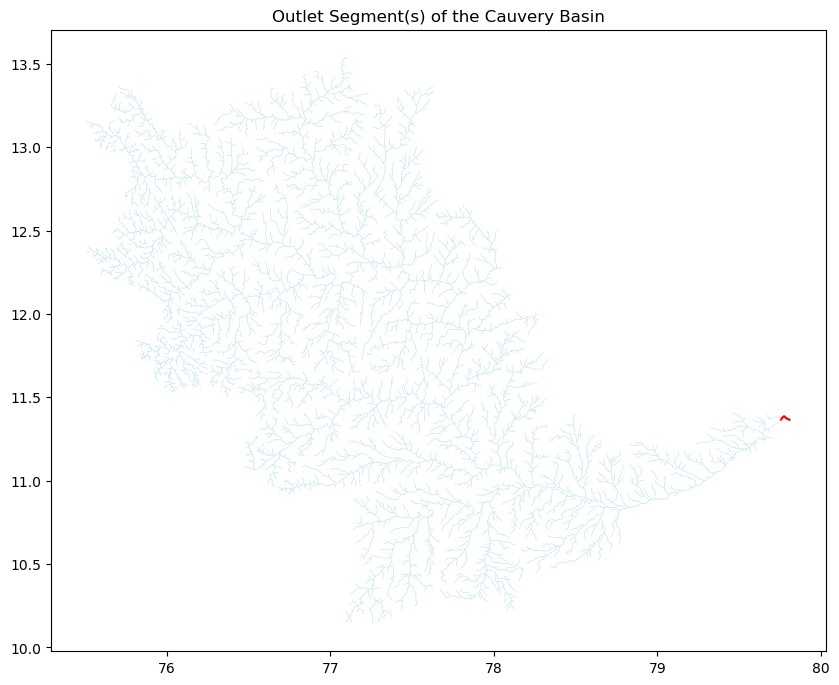

In [17]:
fig, ax = plt.subplots(figsize=(10,10))

cauvery_rivers.plot(
    ax=ax,
    color="lightblue",
    linewidth=0.3
)

outlets.plot(
    ax=ax,
    color="red",
    markersize=60
)

plt.title("Outlet Segment(s) of the Cauvery Basin")
plt.show()

In [ ]:
Section 41.6 – Build the River Connectivity Index

In [18]:
# Dictionary:
# key = downstream segment
# value = list of upstream segments

upstream = {}

for _, row in cauvery_rivers.iterrows():

    nxt = row["NEXT_DOWN"]

    hyriv = row["HYRIV_ID"]

    if nxt not in upstream:
        upstream[nxt] = []

    upstream[nxt].append(hyriv)

print("Dictionary created.")

print("Unique downstream IDs:", len(upstream))

Dictionary created.
Unique downstream IDs: 2248


In [19]:
count = 0

for k, v in upstream.items():

    print(k, " <-- ", v[:5])

    count += 1

    if count == 10:
        break

41388439  <--  [41388960, 41388794, 41388469]
41388469  <--  [41388698, 41388470]
41388891  <--  [41388929, 41388892]
41388758  <--  [41388891, 41388928]
41388697  <--  [41388758, 41388696]
41388345  <--  [41388984, 41388438]
41388437  <--  [41388697, 41388436]
41388344  <--  [41388568, 41388468]
41388216  <--  [41388437, 41388344]
41388178  <--  [41388216, 41388177]


In [20]:
outlet_id = 41376077

print("Segments flowing into the outlet:")

print(upstream[outlet_id])

Segments flowing into the outlet:
[41376732, 41376076]


In [21]:
branches = cauvery_rivers[
    cauvery_rivers["HYRIV_ID"].isin([41376732, 41376076])
]

branches[[
    "HYRIV_ID",
    "UPLAND_SKM",
    "DIS_AV_CMS",
    "ORD_STRA",
    "LENGTH_KM",
    "DIST_UP_KM",
    "DIST_DN_KM"
]]

,HYRIV_ID,UPLAND_SKM,DIS_AV_CMS,ORD_STRA,LENGTH_KM,DIST_UP_KM,DIST_DN_KM
40,41376732,78276.1,306.137,6,10.97,841.3,9.4
42,41376076,49.2,0.714,1,12.43,17.5,9.3


In [22]:
# Create a lookup dictionary by HYRIV_ID
river_lookup = cauvery_rivers.set_index("HYRIV_ID")

In [23]:
main_stem_ids = []

current = 41376077   # Outlet segment

while True:

    # Save current segment
    main_stem_ids.append(current)

    # Stop if no upstream segments
    if current not in upstream:
        break

    upstream_segments = upstream[current]

    # If only one upstream segment, continue
    if len(upstream_segments) == 1:
        current = upstream_segments[0]
        continue

    # If multiple upstream segments,
    # choose the one with the largest upstream area
    best = max(
        upstream_segments,
        key=lambda x: river_lookup.loc[x, "UPLAND_SKM"]
    )

    current = best

print("Main stem segments:", len(main_stem_ids))

Main stem segments: 207


In [24]:
print(main_stem_ids[:20])

[41376077, 41376732, 41376731, 41377030, 41377361, 41377537, 41377703, 41377936, 41378125, 41378222, 41378326, 41378694, 41378921, 41378974, 41378973, 41379416, 41379480, 41380111, 41380596, 41380945]


In [25]:
main_stem = cauvery_rivers[
    cauvery_rivers["HYRIV_ID"].isin(main_stem_ids)
].copy()

print(main_stem.shape)

(207, 15)


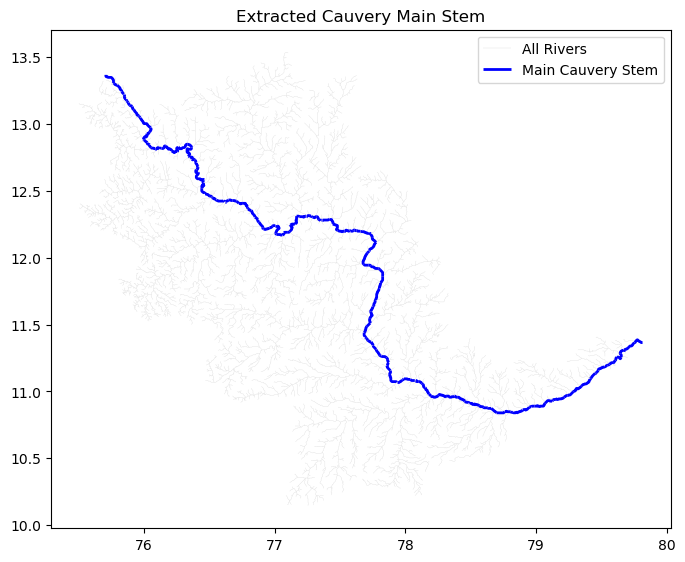

In [26]:
fig, ax = plt.subplots(figsize=(8, 12))

# Entire river network
cauvery_rivers.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.2,
    label="All Rivers"
)

# Main stem
main_stem.plot(
    ax=ax,
    color="blue",
    linewidth=2,
    label="Main Cauvery Stem"
)

plt.legend()
plt.title("Extracted Cauvery Main Stem")
plt.show()